In [2]:
import os,h5py
import neurokit2 as nk
import numpy as np
import matplotlib.pyplot as plt

In [3]:
DATASET_PATH = "/home/intellisense01/EML-Labs/datasets/iridia-af-records-v1.0.1"
RECORD_NAME = "record_077"
record_path = os.path.join(DATASET_PATH, RECORD_NAME)

In [4]:
print(record_path)
os.listdir(record_path)

/home/intellisense01/EML-Labs/datasets/iridia-af-records-v1.0.1/record_077


['record_077_rr_labels.csv',
 'record_077_ecg_00.h5',
 'record_077_rr_00.h5',
 'record_077_ecg_labels.csv']

In [5]:
rr = None
ecg = None
with h5py.File(os.path.join(record_path, "record_077_ecg_00.h5"), "r") as f:
    print(f.keys())
    print(f["ecg"][:][:,1].shape)
    ecg = f["ecg"][:][:,1]
    # rr = f["rr"][:]

<KeysViewHDF5 ['ecg']>
(17278800,)


In [6]:
print(rr)

None


/home/intellisense01/EML-Labs/datasets/Data-Explorer/lib/python3.12/site-packages/neurokit2/ecg/ecg_plot.py:68: NeuroKitWarning: 'info' dict not provided. Some information might be missing. Sampling rate will be set to 1000 Hz.
  warn(


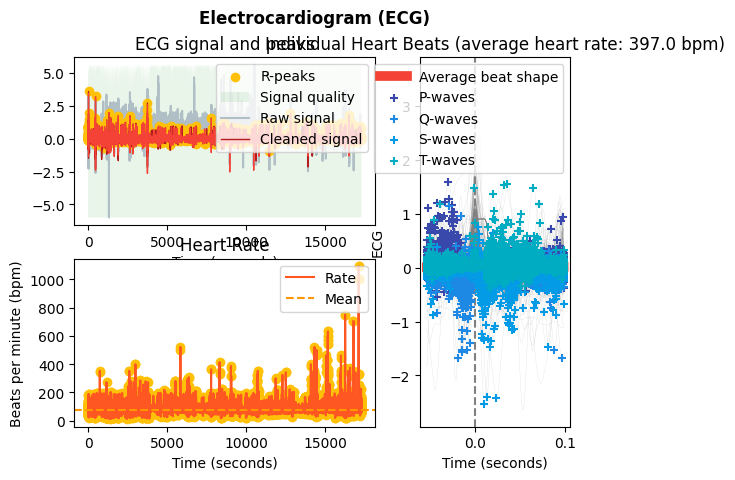

In [9]:
ecg_clean,info = nk.ecg_process(ecg, sampling_rate=200)
nk.ecg_plot(ecg_clean)

In [ ]:
PROCESSED_DATA_DIR = "/home/intellisense01/EML-Labs/datasets/Data-Explorer/processed_data_35_min"
data = np.load(os.path.join(PROCESSED_DATA_DIR, "record_153_af2833s_nsr49131s_rr.npy"))

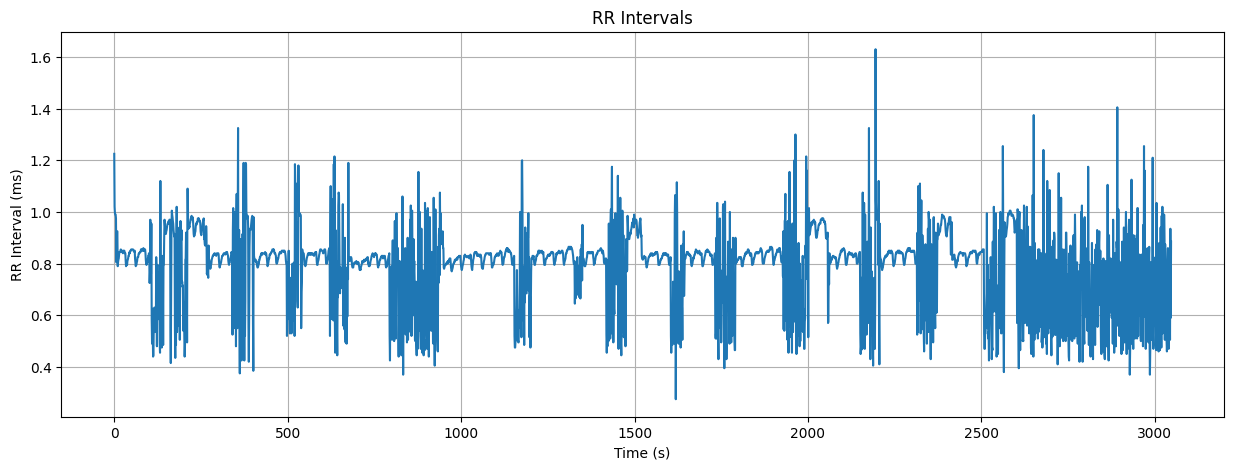

In [8]:
plt.figure(figsize=(15,5))
plt.plot(data)
plt.title("RR Intervals")
plt.xlabel("Time (s)")
plt.ylabel("RR Interval (ms)")
plt.grid()
plt.show()

In [46]:
list_of_files = os.listdir(PROCESSED_DATA_DIR)
print(list_of_files[:10])

FileNotFoundError: [Errno 2] No such file or directory: '/home/intellisense01/EML-Labs/datasets/Data-Explorer/processed_data'

In [ ]:
data = []
for file in list_of_files[:10]
    if file.endswith(".npy"):
        data.append(np.load(os.path.join(PROCESSED_DATA_DIR, file)))

In [12]:
min_length = min(len(d) for d in data)
data = [d[-min_length:] for d in data] # Truncate to the shortest length
data = np.array(data)
print(data.shape)

(231, 565)


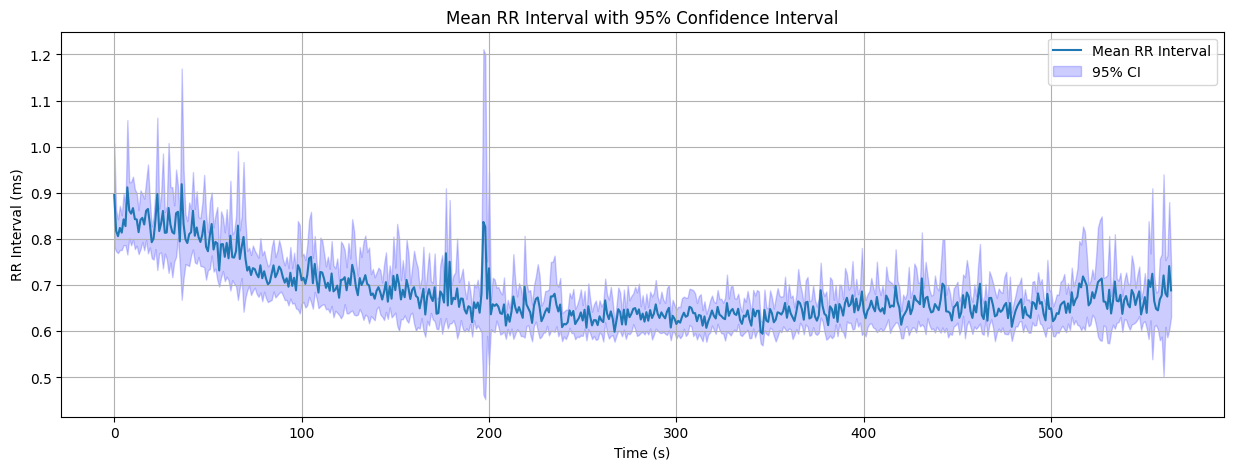

In [13]:
mean_windows = np.mean(data, axis=0)
std_windows = np.std(data, axis=0)
ci_95 = 1.96 * std_windows / np.sqrt(data.shape[0])
plt.figure(figsize=(15,5))
plt.plot(mean_windows, label="Mean RR Interval")
plt.fill_between(range(len(mean_windows)), mean_windows - ci_95, mean_windows + ci_95, color='b', alpha=0.2, label="95% CI")
plt.title("Mean RR Interval with 95% Confidence Interval")
plt.xlabel("Time (s)")
plt.ylabel("RR Interval (ms)")
plt.legend()
plt.grid()
plt.show()

In [37]:
def RMSSD(rr_intervals):
    diff = np.diff(rr_intervals)
    return np.sqrt(np.mean(diff**2))

def pNN50(rr_intervals):
    diff = np.diff(rr_intervals)
    return np.sum(np.abs(diff) > 0.05) / len(diff) * 100 # Since RR intervals in seconds, 50ms = 0.05s

def SDNN(rr_intervals):
    return np.std(rr_intervals)

def sample_entropy(rr_intervals, m=2, r=0.2):
    sample_entropy_, _ = nk.entropy_sample(rr_intervals, dimension=m, tolerance=r * np.std(rr_intervals))
    return sample_entropy_

def approximate_entropy(rr_intervals, m=2, r=0.2):
    approximate_entropy_, _ = nk.entropy_approximate(rr_intervals, dimension=m, tolerance=r * np.std(rr_intervals))
    return approximate_entropy_

def alpha_1(rr_intervals):
    alpha_1_, _ = nk.complexity_dfa(rr_intervals, order=1)
    return alpha_1_

In [38]:
random_sample_entropy = sample_entropy(np.random.rand(1000))
print(f"Sample Entropy of random data: {random_sample_entropy}")

random_approx_entropy = approximate_entropy(np.random.rand(1000))
print(f"Approximate Entropy of random data: {random_approx_entropy}")

Sample Entropy of random data: 2.207735431206342
Approximate Entropy of random data: 1.8086346541355072


In [39]:
window_length = 200 # 200 RR intervals
stride = 10 # 10 RR interval stride
rmssd_values = []
pnn50_values = []
alpha1_values = []
sample_entropy_values = []
approximate_entropy_values = []
for record in data:
    rmssd_record = []
    pnn50_record = []
    alpha_1_record = []
    sample_entropy_record = []
    approximate_entropy_record = []
    for start in range(0, len(record) - window_length + 1, stride):
        window = record[start:start+window_length]
        rmssd_record.append(RMSSD(window))
        pnn50_record.append(pNN50(window))
        alpha_1_record.append(alpha_1(window))
        sample_entropy_record.append(sample_entropy(window))
        approximate_entropy_record.append(approximate_entropy(window))

    rmssd_values.append(rmssd_record)
    pnn50_values.append(pnn50_record)
    alpha1_values.append(alpha_1_record)
    sample_entropy_values.append(sample_entropy_record)
    approximate_entropy_values.append(approximate_entropy_record)
    

In [40]:
print(len(data))
print(len(rmssd_values))
print(len(rmssd_values[0]))
print(len(pnn50_values))

231
231
37
231


In [ ]:
mean_rmssd = np.mean(rmssd_values, axis=0)
std_rmssd = np.std(rmssd_values, axis=0)
ci_95_rmssd = 1.96 * std_rmssd / np.sqrt(len(rmssd_values))
plt.figure(figsize=(15,5))
plt.plot(mean_rmssd, label="Mean RMSSD")
plt.fill_between(range(len(mean_rmssd)), mean_rmssd - ci_95_rmssd, mean_rmssd + ci_95_rmssd, color='b', alpha=0.2, label="95% CI")
plt.title("Mean RMSSD with 95% Confidence Interval")
plt.xlabel("Time (s)")
plt.ylabel("RMSSD (s)")
plt.legend()
plt.grid()
plt.show()

SyntaxError: invalid syntax (476840140.py, line 1)

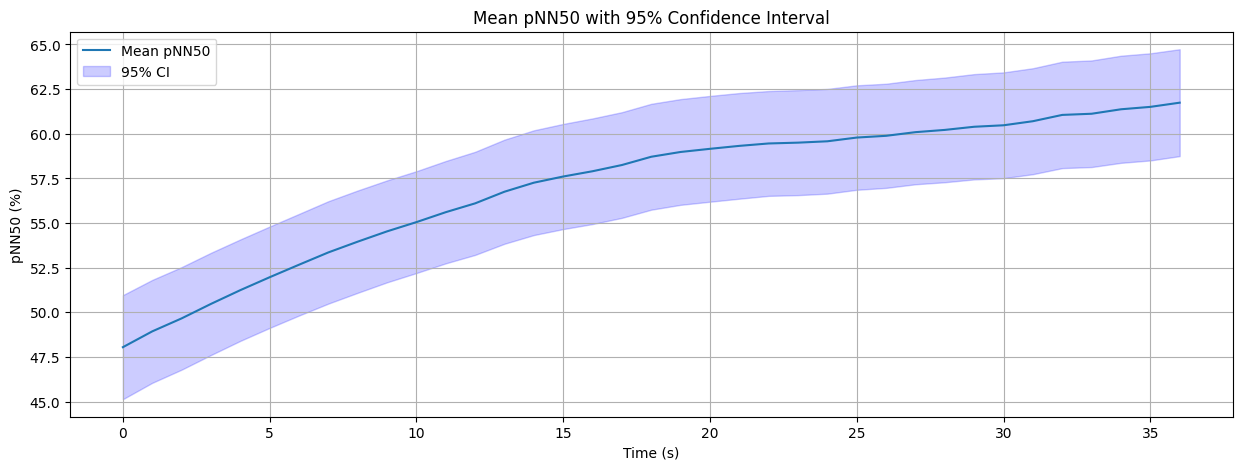

In [42]:
mean_pnn50 = np.mean(pnn50_values, axis=0)
std_pnn50 = np.std(pnn50_values, axis=0)
ci_95_pnn50 = 1.96 * std_pnn50 / np.sqrt(len(pnn50_values))
plt.figure(figsize=(15,5))
plt.plot(mean_pnn50, label="Mean pNN50")
plt.fill_between(range(len(mean_pnn50)), mean_pnn50 - ci_95_pnn50, mean_pnn50 + ci_95_pnn50, color='b', alpha=0.2, label="95% CI")
plt.title("Mean pNN50 with 95% Confidence Interval")
plt.xlabel("Time (s)")      
plt.ylabel("pNN50 (%)")
plt.legend()
plt.grid()
plt.show()

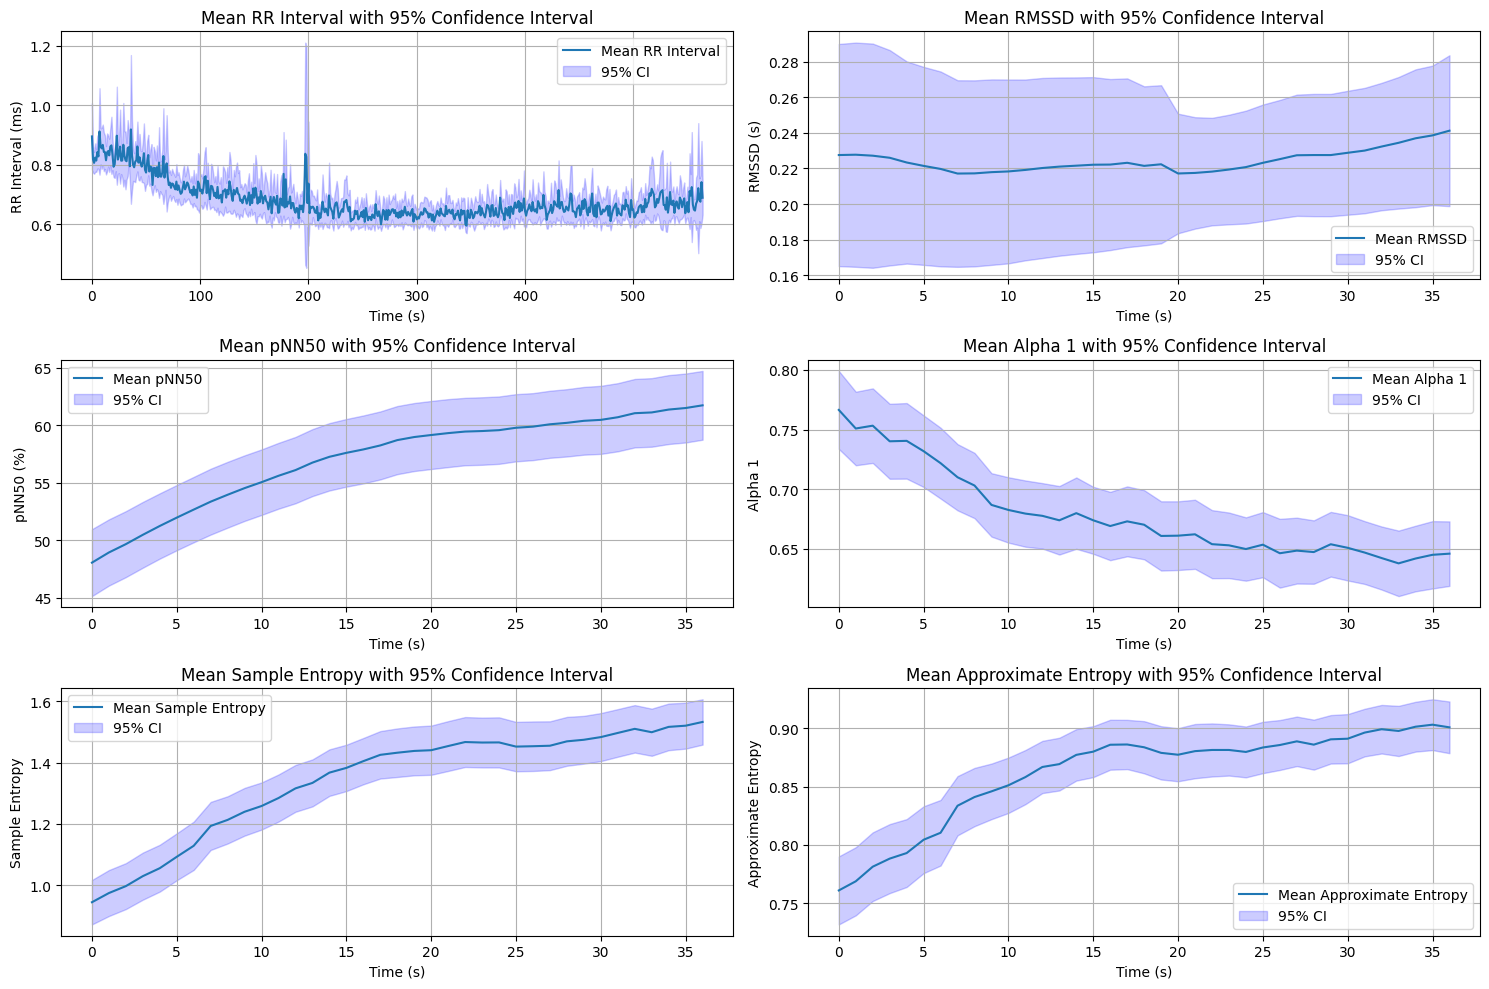

In [45]:
mean_rr = np.mean(data, axis=0)
std_rr = np.std(data, axis=0)
ci_95_rr = 1.96 * std_rr / np.sqrt(data.shape[0])


mean_rmssd = np.mean(rmssd_values, axis=0)
std_rmssd = np.std(rmssd_values, axis=0)
ci_95_rmssd = 1.96 * std_rmssd / np.sqrt(len(rmssd_values))

mean_pnn50 = np.mean(pnn50_values, axis=0)
std_pnn50 = np.std(pnn50_values, axis=0)
ci_95_pnn50 = 1.96 * std_pnn50 / np.sqrt(len(pnn50_values))

mean_alpha1 = np.mean(alpha1_values, axis=0)
std_alpha1 = np.std(alpha1_values, axis=0)
ci_95_alpha1 = 1.96 * std_alpha1 / np.sqrt(len(alpha1_values))

mean_sample_entropy = np.mean(sample_entropy_values, axis=0)
std_sample_entropy = np.std(sample_entropy_values, axis=0)
ci_95_sample_entropy = 1.96 * std_sample_entropy / np.sqrt(len(sample_entropy_values))

mean_approximate_entropy = np.mean(approximate_entropy_values, axis=0)
std_approximate_entropy = np.std(approximate_entropy_values, axis=0)
ci_95_approximate_entropy = 1.96 * std_approximate_entropy / np.sqrt(len(approximate_entropy_values))

plt.figure(figsize=(15,10))
plt.subplot(3,2,1)
plt.plot(mean_rr, label="Mean RR Interval")
plt.fill_between(range(len(mean_rr)), mean_rr - ci_95_rr, mean_rr + ci_95_rr, color='b', alpha=0.2, label="95% CI")
plt.title("Mean RR Interval with 95% Confidence Interval")
plt.xlabel("Time (s)")
plt.ylabel("RR Interval (ms)")
plt.legend()
plt.grid()

plt.subplot(3,2,2)
plt.plot(mean_rmssd, label="Mean RMSSD")
plt.fill_between(range(len(mean_rmssd)), mean_rmssd - ci_95_rmssd, mean_rmssd + ci_95_rmssd, color='b', alpha=0.2, label="95% CI")
plt.title("Mean RMSSD with 95% Confidence Interval")
plt.xlabel("Time (s)")
plt.ylabel("RMSSD (s)")
plt.legend()
plt.grid()  

plt.subplot(3,2,3)
plt.plot(mean_pnn50, label="Mean pNN50")
plt.fill_between(range(len(mean_pnn50)), mean_pnn50 - ci_95_pnn50, mean_pnn50 + ci_95_pnn50, color='b', alpha=0.2, label="95% CI")
plt.title("Mean pNN50 with 95% Confidence Interval")
plt.xlabel("Time (s)")
plt.ylabel("pNN50 (%)")
plt.legend()
plt.grid()

plt.subplot(3,2,4)
plt.plot(mean_alpha1, label="Mean Alpha 1")
plt.fill_between(range(len(mean_alpha1)), mean_alpha1 - ci_95_alpha1, mean_alpha1 + ci_95_alpha1, color='b', alpha=0.2, label="95% CI")
plt.title("Mean Alpha 1 with 95% Confidence Interval")
plt.xlabel("Time (s)")
plt.ylabel("Alpha 1")
plt.legend()
plt.grid()

plt.subplot(3,2,5)
plt.plot(mean_sample_entropy, label="Mean Sample Entropy")
plt.fill_between(range(len(mean_sample_entropy)), mean_sample_entropy - ci_95_sample_entropy, mean_sample_entropy + ci_95_sample_entropy, color='b', alpha=0.2, label="95% CI")
plt.title("Mean Sample Entropy with 95% Confidence Interval")
plt.xlabel("Time (s)")
plt.ylabel("Sample Entropy")
plt.legend()
plt.grid()

plt.subplot(3,2,6)
plt.plot(mean_approximate_entropy, label="Mean Approximate Entropy")
plt.fill_between(range(len(mean_approximate_entropy)), mean_approximate_entropy - ci_95_approximate_entropy, mean_approximate_entropy + ci_95_approximate_entropy, color='b', alpha=0.2, label="95% CI")
plt.title("Mean Approximate Entropy with 95% Confidence Interval")
plt.xlabel("Time (s)")
plt.ylabel("Approximate Entropy")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("comparison_of_different_metrics.png", dpi=300, bbox_inches='tight')
plt.show()